In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

plt.style.use('default')

def save_simple_tex(df, filename, caption, label):
    df_out = df.copy()
    
    def fmt(x):
        if isinstance(x, (float, np.floating)):
            if abs(x) < 1e-10: return "0.0000"
            if abs(x) < 0.001: return "{:.2e}".format(x)
            return "{:.4f}".format(x)
        return x
    
    df_out = df_out.applymap(fmt)

    new_cols = []
    for col in df_out.columns:
        c = str(col)
        c = c.replace("Manual", "Man").replace("Library", "Lib")
        c = c.replace("Prediction", "Pred").replace("Observation", "Obs")
        c = c.replace("Confidence Interval", "CI").replace("Difference", "Diff")
        c = c.replace("Lower", "Low").replace("Upper", "High")
        c = c.replace("Intercept", "Int").replace("Slope", "Slp")
        c = c.replace("Współczynnik", "Coef")
        new_cols.append(c)
    df_out.columns = new_cols

    df_out.to_latex(
        filename,
        index=True,
        caption=caption,
        label=label,
        position="H",          # Wymusza pozycję w LaTeX
        column_format="l" + "c"*len(df_out.columns), # Lewy indeks, reszta środek
        escape=False
    )
    print(f"[OK] Wygenerowano: {filename}")

In [2]:
data = pd.read_csv('CH01PR20.txt', sep=r'\s+', header=None, names=['Time', 'Copiers'])
X = data['Copiers']
y = data['Time']

n = len(X)
X_mean = np.mean(X)
y_mean = np.mean(y)

numerator = np.sum((X - X_mean) * (y - y_mean))
denominator = np.sum((X - X_mean) ** 2) # Sxx

b1_man = numerator / denominator
b0_man = y_mean - b1_man * X_mean

y_pred_man = b0_man + b1_man * X
residuals = y - y_pred_man
SSE = np.sum(residuals ** 2)
MSE = SSE / (n - 2)
s = np.sqrt(MSE) 
Sxx = denominator

# Błędy standardowe (SE)
se_b1_man = s / np.sqrt(Sxx)
se_b0_man = s * np.sqrt(1/n + (X_mean**2) / Sxx)

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const)
res_sm = model.fit()

print("Obliczenia zakończone.")

Obliczenia zakończone.


In [3]:
t_crit = stats.t.ppf(1 - 0.05/2, df=n-2)

# Obliczamy p-value ręcznie
t_b0 = b0_man / se_b0_man
t_b1 = b1_man / se_b1_man
p_b0 = 2 * (1 - stats.t.cdf(abs(t_b0), df=n-2))
p_b1 = 2 * (1 - stats.t.cdf(abs(t_b1), df=n-2))

df_params = pd.DataFrame({
    'Man Coef': [b0_man, b1_man],
    'Lib Coef': res_sm.params.values,
    'Man SE': [se_b0_man, se_b1_man],
    'Lib SE': res_sm.bse.values,
    'Man P-val': [p_b0, p_b1],
    'Lib P-val': res_sm.pvalues.values
}, index=['Intercept', 'Slope'])

save_simple_tex(df_params, 'tab_params.tex', 'Porównanie parametrów modelu', 'tab:params')

[OK] Wygenerowano: tab_params.tex


/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_8913/1066935895.py:19: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_out = df_out.applymap(fmt)


In [4]:
k_values = [1, 5, 8, 11, 25, 100]

results_k = []
for k in k_values:
    y_h = b0_man + b1_man * k
    
    se_mean = s * np.sqrt(1/n + (k - X_mean)**2 / Sxx)
    ci_low = y_h - t_crit * se_mean
    ci_high = y_h + t_crit * se_mean
    
    se_pred = s * np.sqrt(1 + 1/n + (k - X_mean)**2 / Sxx)
    pi_low = y_h - t_crit * se_pred
    pi_high = y_h + t_crit * se_pred
    
    results_k.append([k, y_h, ci_low, ci_high, pi_low, pi_high])

df_res = pd.DataFrame(results_k, columns=['k', 'Pred', 'Man CI Low', 'Man CI High', 'Man PI Low', 'Man PI High'])

pred_obj = res_sm.get_prediction(sm.add_constant(k_values))
sm_frame = pred_obj.summary_frame(alpha=0.05)

df_ci = pd.DataFrame({
    'k': k_values,
    'Man CI Low': df_res['Man CI Low'],
    'Lib CI Low': sm_frame['mean_ci_lower'].values,
    'Man CI High': df_res['Man CI High'],
    'Lib CI High': sm_frame['mean_ci_upper'].values
}).set_index('k')

df_pi = pd.DataFrame({
    'k': k_values,
    'Man PI Low': df_res['Man PI Low'],
    'Lib PI Low': sm_frame['obs_ci_lower'].values,
    'Man PI High': df_res['Man PI High'],
    'Lib PI High': sm_frame['obs_ci_upper'].values
}).set_index('k')

save_simple_tex(df_ci, 'tab_ci.tex', 'Porównanie CI dla wartości oczekiwanej', 'tab:ci')
save_simple_tex(df_pi, 'tab_pi.tex', 'Porównanie PI dla nowej obserwacji', 'tab:pi')

[OK] Wygenerowano: tab_ci.tex
[OK] Wygenerowano: tab_pi.tex


/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_8913/1066935895.py:19: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_out = df_out.applymap(fmt)


[OK] Wygenerowano: wykres_zad1.png


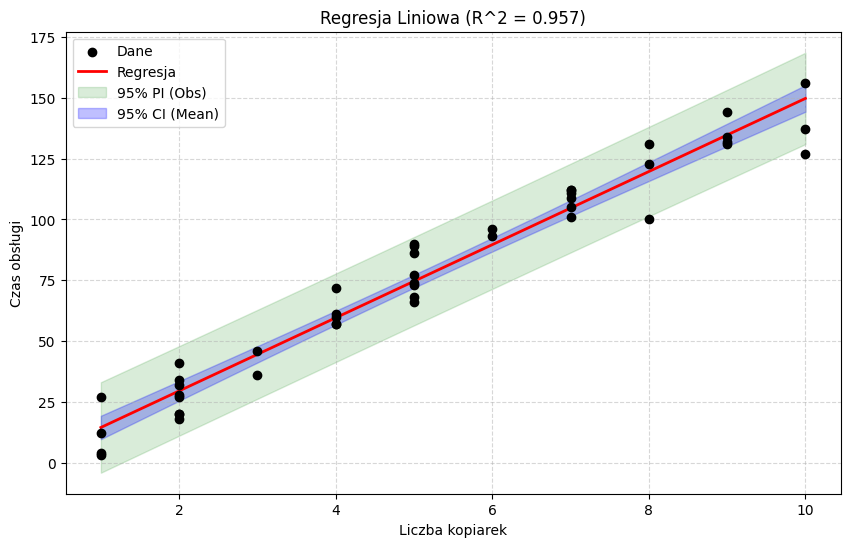

In [5]:
x_grid = np.linspace(X.min(), X.max(), 100)
pred_grid = res_sm.get_prediction(sm.add_constant(x_grid)).summary_frame(alpha=0.05)

plt.figure(figsize=(10, 6))

# 1. Dane
plt.scatter(X, y, color='black', label='Dane', zorder=5)

# 2. Linia regresji
plt.plot(x_grid, pred_grid['mean'], color='red', linewidth=2, label='Regresja')

# 3. Pasmo PI 
plt.fill_between(x_grid, pred_grid['obs_ci_lower'], pred_grid['obs_ci_upper'], 
                 color='green', alpha=0.15, label='95% PI (Obs)')

# 4. Pasmo CI 
plt.fill_between(x_grid, pred_grid['mean_ci_lower'], pred_grid['mean_ci_upper'], 
                 color='blue', alpha=0.25, label='95% CI (Mean)')

plt.xlabel('Liczba kopiarek')
plt.ylabel('Czas obsługi')
plt.title(f'Regresja Liniowa (R^2 = {res_sm.rsquared:.3f})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('wykres_zad1.png')
print("[OK] Wygenerowano: wykres_zad1.png")
plt.show()